In [3]:
import numpy as np

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


INSIGHTS:

Glucose, BMI, Age show wide variation

Several columns have minimum value = 0, which is medically invalid

In [6]:
invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

(df[invalid_cols] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [7]:
df[invalid_cols] = df[invalid_cols].replace(0, np.nan)


In [8]:
for col in invalid_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_28124\2925831940.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


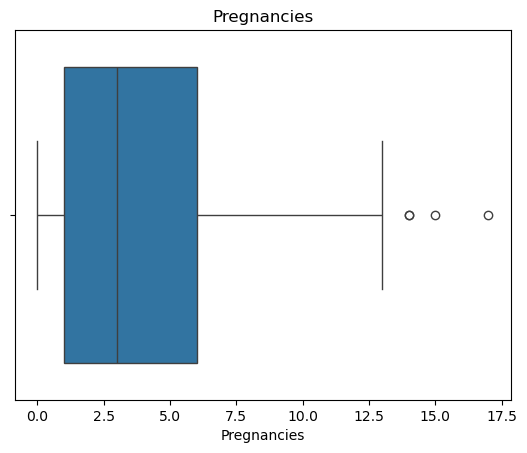

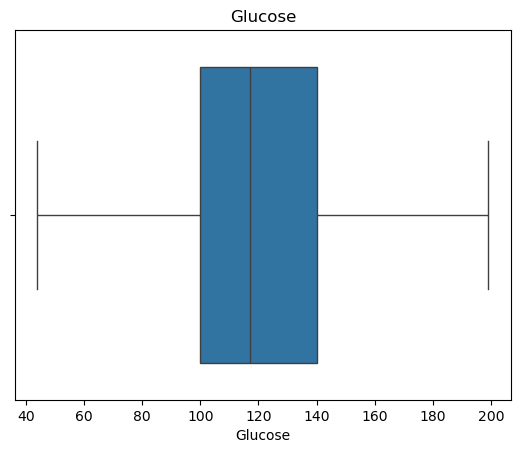

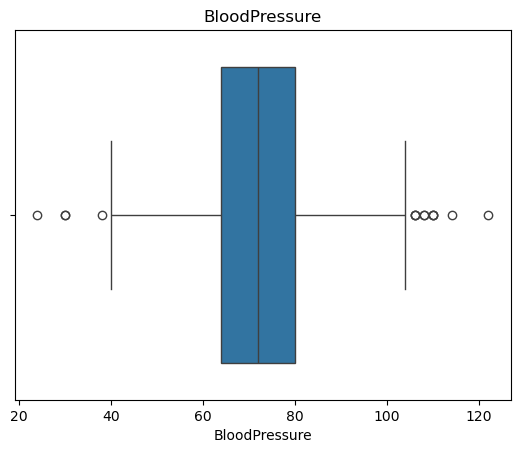

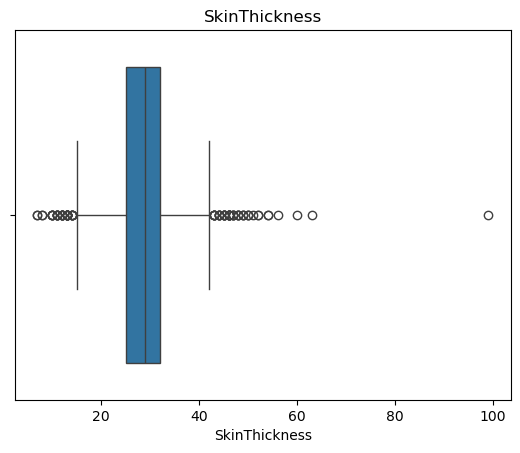

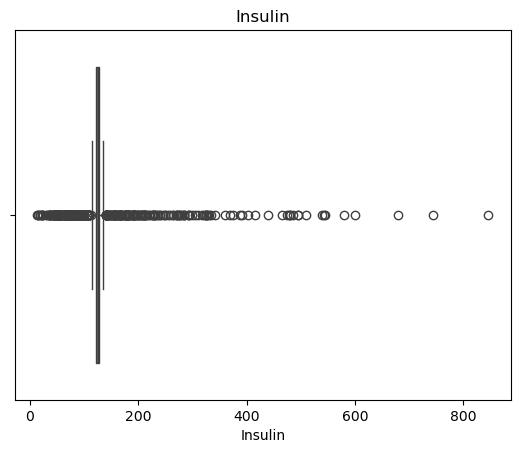

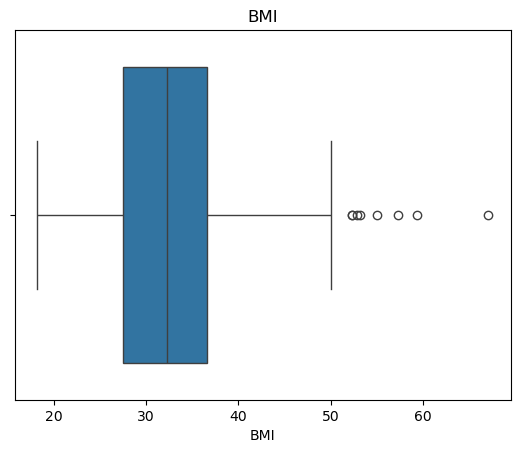

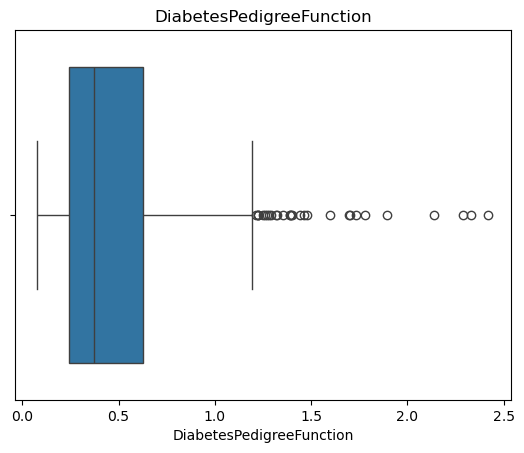

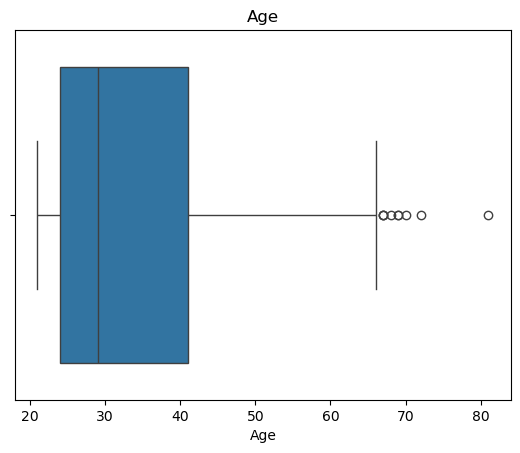

In [9]:
numerical_cols = df.drop(columns='Outcome').columns

for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


Outliers present in Insulin, BMI, DiabetesPedigreeFunction, Age

In [10]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)



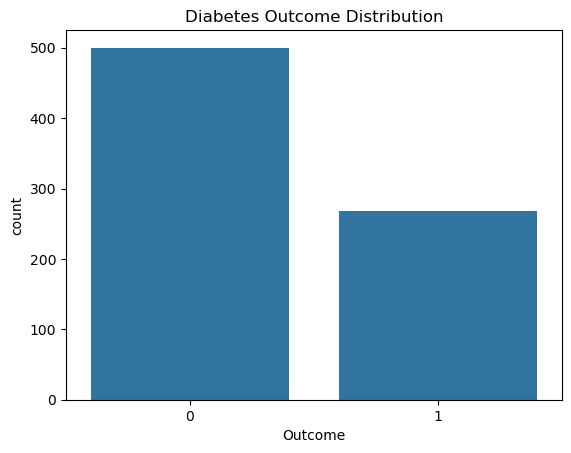

In [11]:
sns.countplot(x=df['Outcome'])
plt.title("Diabetes Outcome Distribution")
plt.show()

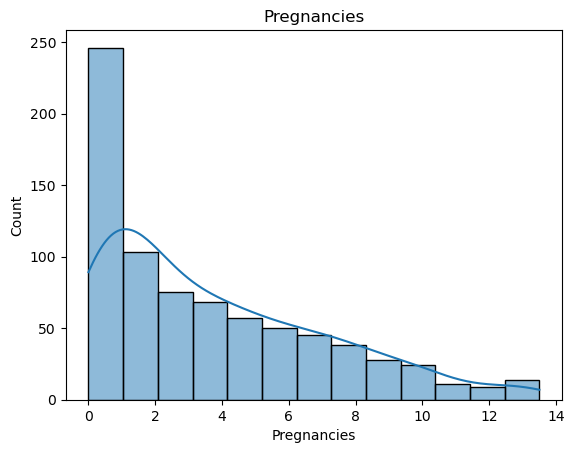

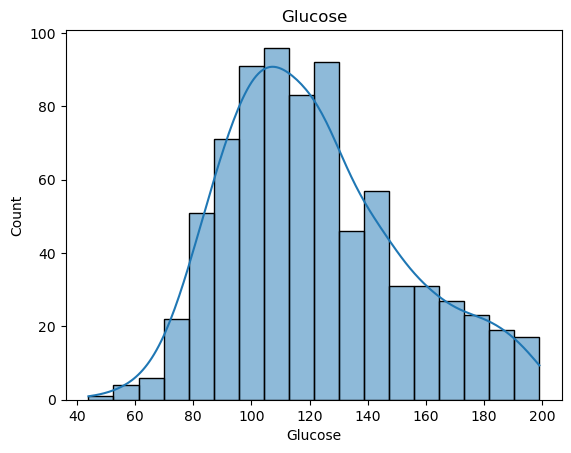

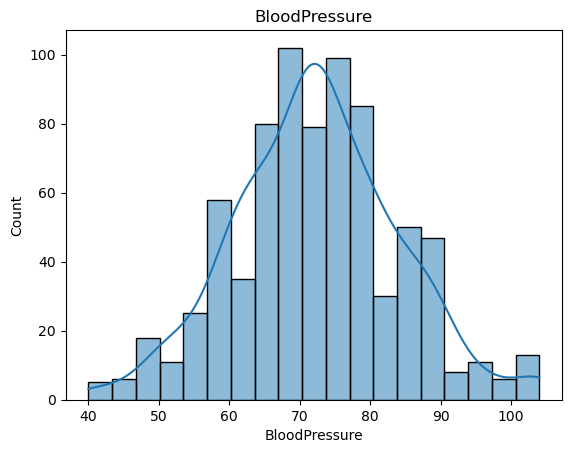

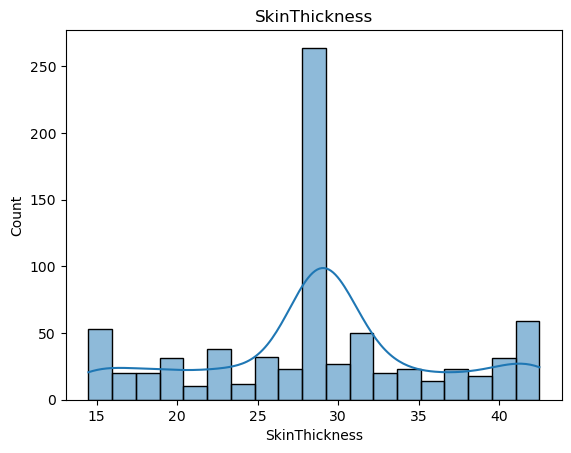

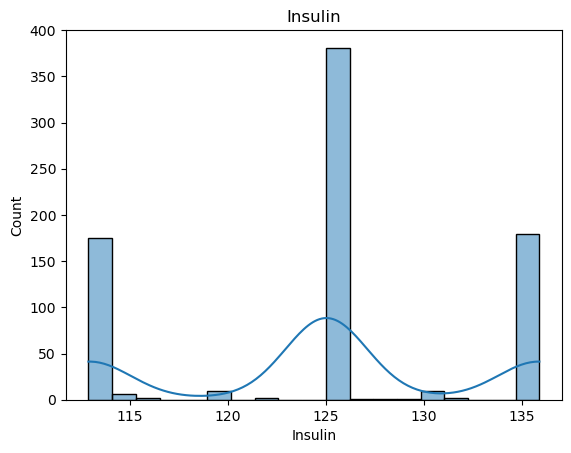

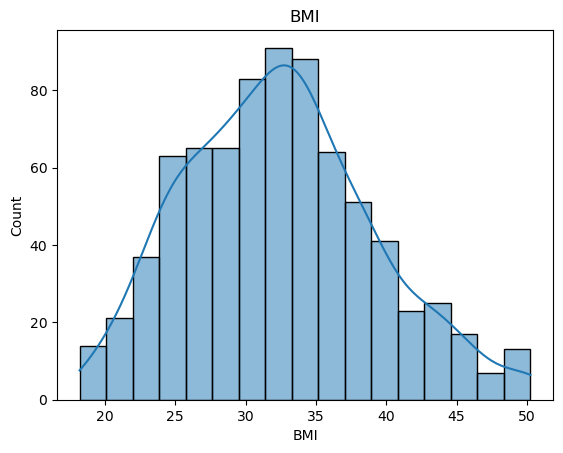

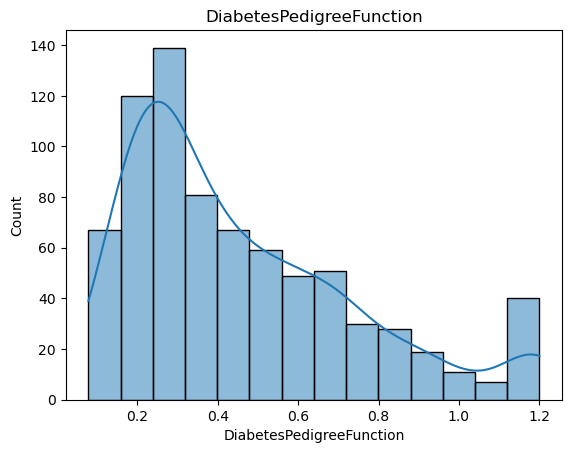

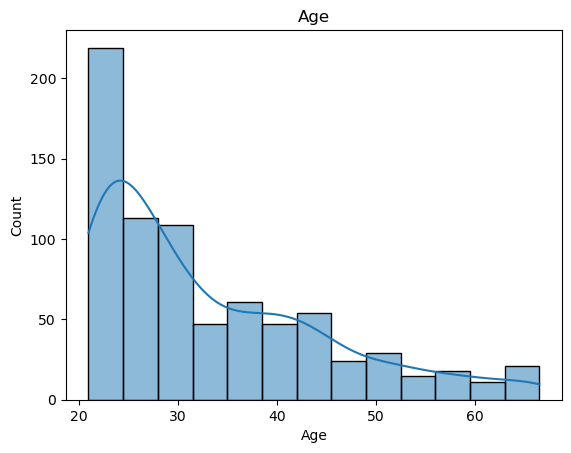

In [12]:
for col in numerical_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


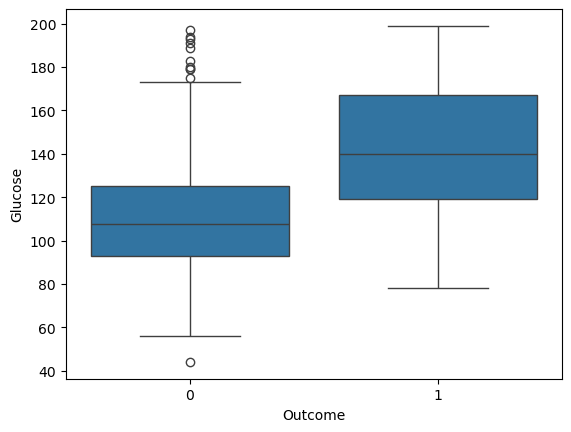

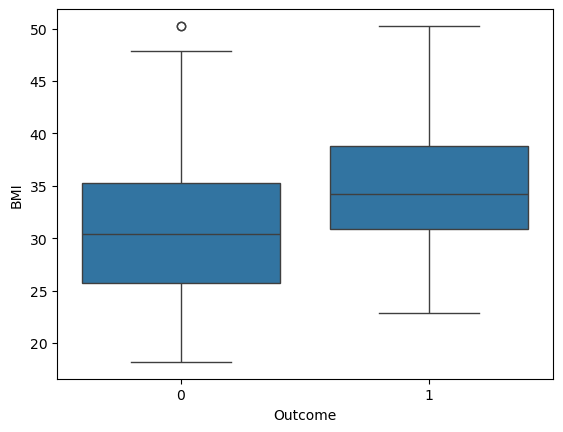

In [13]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.show()

sns.boxplot(x='Outcome', y='BMI', data=df)
plt.show()


In [14]:
corr = df.corr()


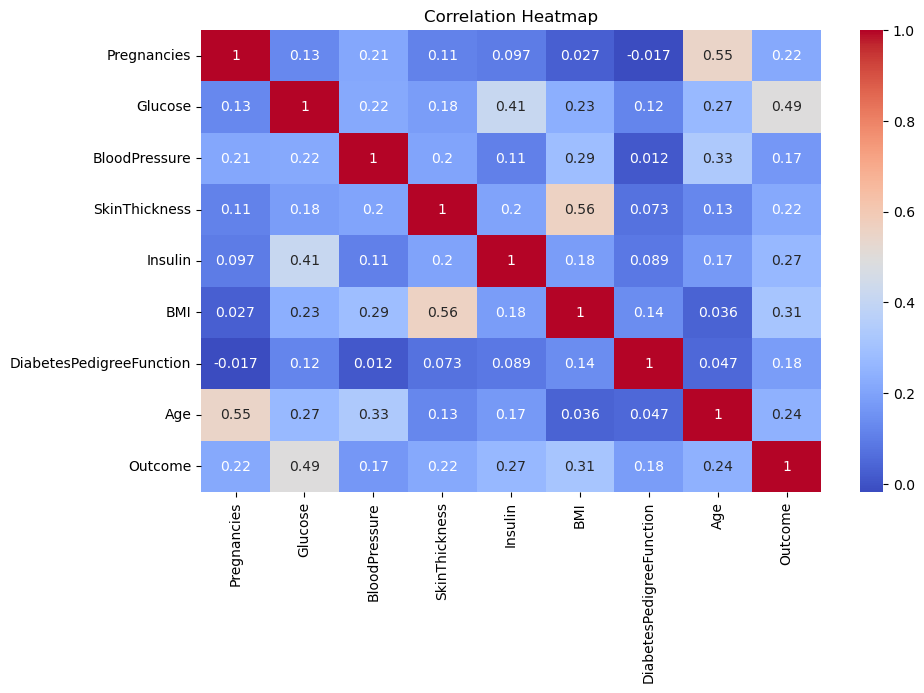

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Glucose has the strongest positive correlation with diabetes outcome

BMI and Age also show moderate correlation

Insulin has high variance and outliers

Zero values required domain-specific treatment

Dataset is now clean and ready for modeling

In [16]:
min_values=df.min()
max_values=df.max()
print(min_values)
print(max_values)

Pregnancies                   0.000
Glucose                      44.000
BloodPressure                40.000
SkinThickness                14.500
Insulin                     112.875
BMI                          18.200
DiabetesPedigreeFunction      0.078
Age                          21.000
Outcome                       0.000
dtype: float64
Pregnancies                  13.500
Glucose                     199.000
BloodPressure               104.000
SkinThickness                42.500
Insulin                     135.875
BMI                          50.250
DiabetesPedigreeFunction      1.200
Age                          66.500
Outcome                       1.000
dtype: float64


Glucose (Fasting)

Normal: 70–99 mg/dL

Prediabetes: 100–125 mg/dL

Diabetes: ≥126 mg/dL

Blood Pressure (Diastolic)

Low: <60 mm Hg

Normal: 60–80 mm Hg

High: >80 mm Hg

Skin Thickness

Normal Range: 10–50 mm

Indicates subcutaneous fat and body composition

Insulin (2-Hour)

Normal Range: 16–166 µIU/mL

High values indicate insulin resistance

Body Mass Index (BMI)

Underweight: <18.5

Normal: 18.5–24.9

Overweight: 25–29.9

Obese: ≥30

Diabetes Pedigree Function

Range: 0.0–2.5

Higher values indicate stronger genetic risk

In [17]:
import numpy as np

cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_zero:
    median_val = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median_val)

In [25]:
print(df[cols_with_zero].head())

   Glucose  BloodPressure  SkinThickness  Insulin   BMI
0    148.0           72.0           35.0  125.000  33.6
1     85.0           66.0           29.0  125.000  26.6
2    183.0           64.0           29.0  125.000  23.3
3     89.0           66.0           23.0  112.875  28.1
4    137.0           40.0           35.0  135.875  43.1


<Axes: xlabel='Age'>

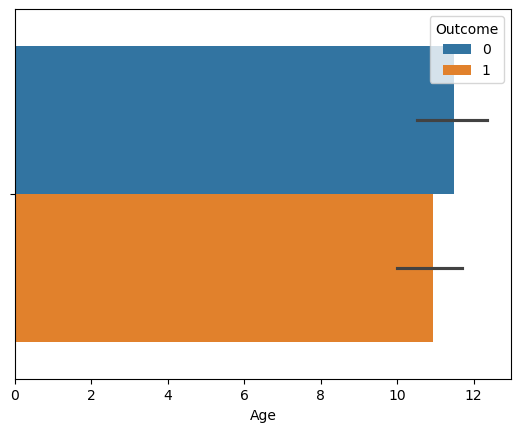

In [26]:
sns.barplot(x=df['Age' ],hue=df['Outcome' ], estimator='std')

<Axes: xlabel='Age', ylabel='Outcome'>

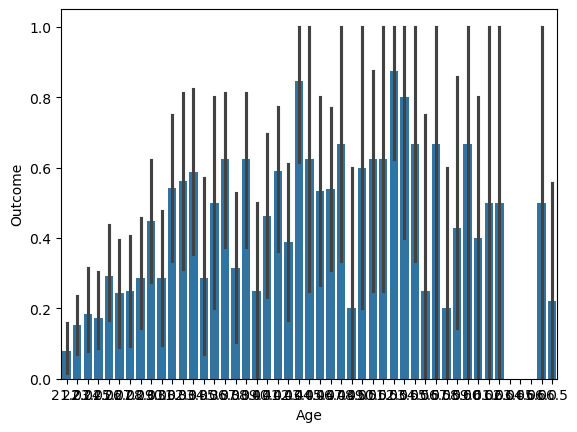

In [28]:
sns.barplot(x=df['Age'],y=df['Outcome'],estimator='mean')

<Axes: xlabel='Age', ylabel='Count'>

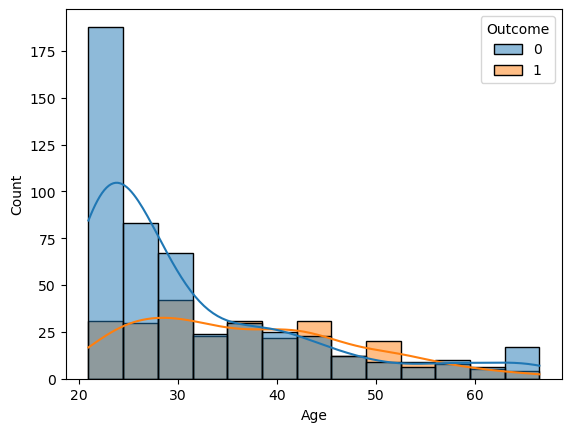

In [27]:
sns.histplot(x='Age',hue='Outcome',data=df,kde=True)

In [29]:
df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

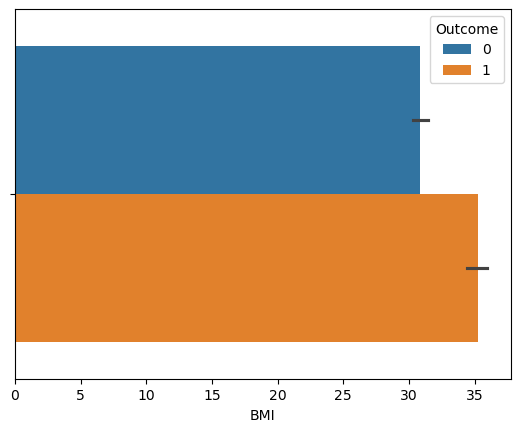

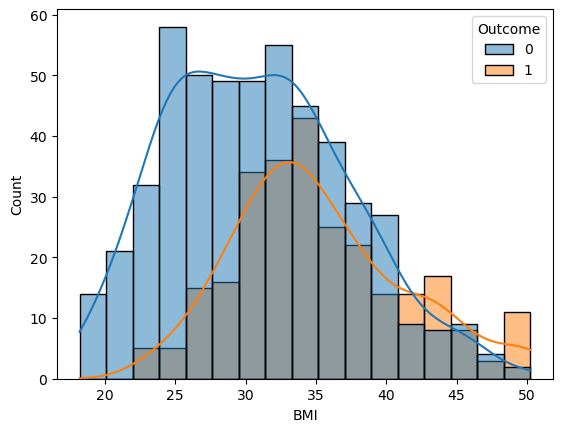

In [30]:
df['BMI'].groupby(df['Outcome']).count()
sns.barplot(x="BMI", hue="Outcome", data=df,estimator="mean")
plt.show()
sns.histplot(x='BMI',hue='Outcome',data=df,kde=True)
plt.show()

In [31]:
cols = ["Age","Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI","DiabetesPedigreeFunction"]
for col in cols:
  die_age=df[col][df['Outcome'] == 1]
  nondie_age=df[col][df['Outcome'] == 0]

  # H0 : Both data are same
  # H1 : Both are not same
  from scipy.stats import ttest_ind

  stat, p = ttest_ind(die_age, nondie_age)

  alpha = 0.05
  if p<alpha:
    print(col,' : Reject H0')
  else:
    print(col,' : Accept H0')

Age  : Reject H0
Glucose  : Reject H0
BloodPressure  : Reject H0
SkinThickness  : Reject H0
Insulin  : Reject H0
BMI  : Reject H0
DiabetesPedigreeFunction  : Reject H0


In [32]:
cols = [
    "Age",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction"
]

In [33]:
# Mean of each feature grouped by Outcome

for col in cols:
    print(f"\nMean of {col} by Outcome")
    print(df.groupby("Outcome")[col].mean())


Mean of Age by Outcome
Outcome
0    31.135000
1    37.052239
Name: Age, dtype: float64

Mean of Glucose by Outcome
Outcome
0    110.682000
1    142.130597
Name: Glucose, dtype: float64

Mean of BloodPressure by Outcome
Outcome
0    70.91200
1    75.05597
Name: BloodPressure, dtype: float64

Mean of SkinThickness by Outcome
Outcome
0    27.668000
1    31.102612
Name: SkinThickness, dtype: float64

Mean of Insulin by Outcome
Outcome
0    123.148750
1    127.568563
Name: Insulin, dtype: float64

Mean of BMI by Outcome
Outcome
0    30.867400
1    35.240299
Name: BMI, dtype: float64

Mean of DiabetesPedigreeFunction by Outcome
Outcome
0    0.420264
1    0.531022
Name: DiabetesPedigreeFunction, dtype: float64


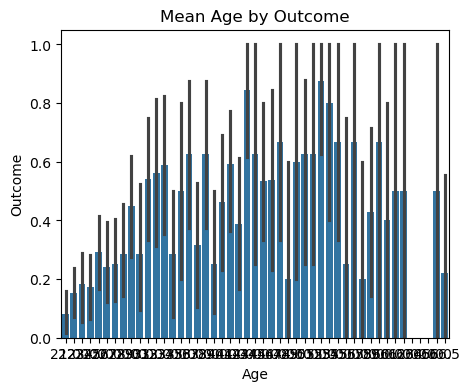

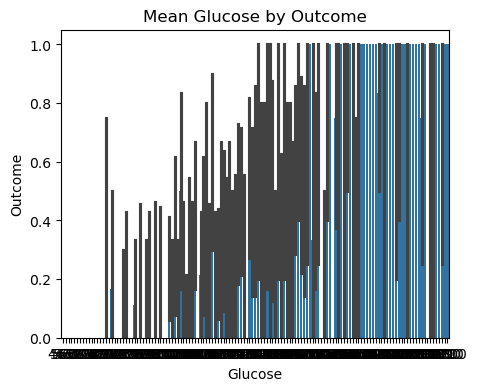

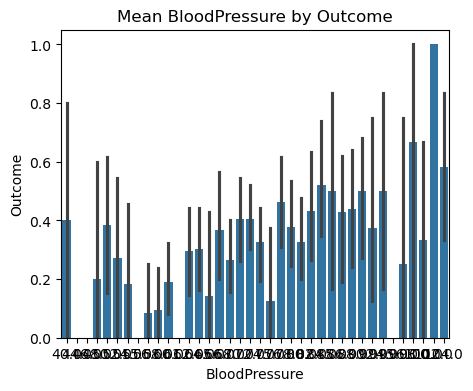

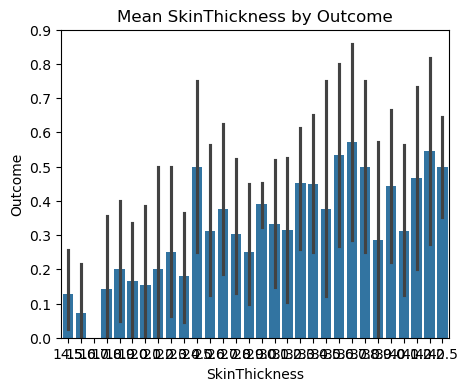

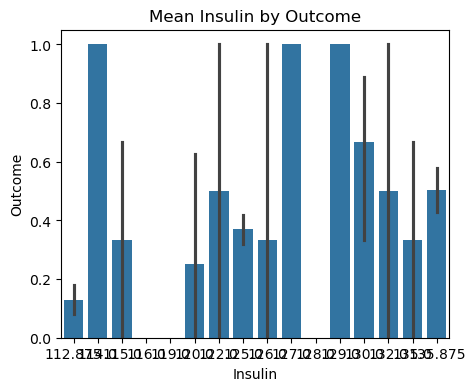

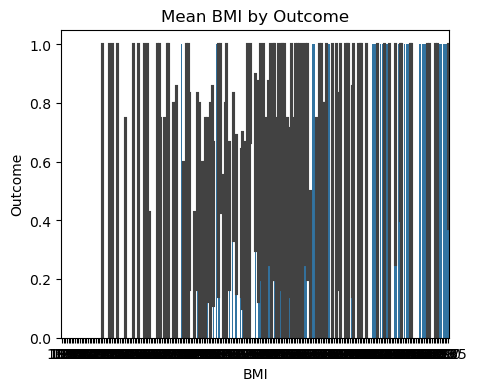

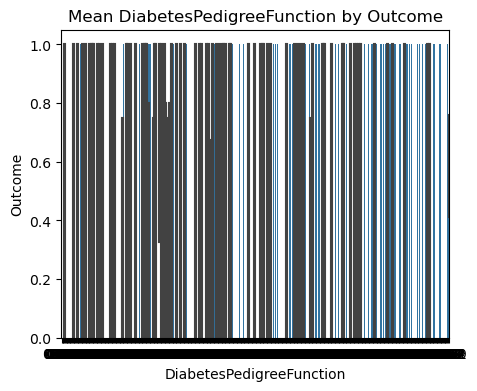

In [34]:
# Barplot – Mean value of feature vs Outcome

import seaborn as sns
import matplotlib.pyplot as plt

for col in cols:
    plt.figure(figsize=(5,4))
    sns.barplot(x=col, y="Outcome", data=df, estimator="mean")
    plt.title(f"Mean {col} by Outcome")
    plt.show()

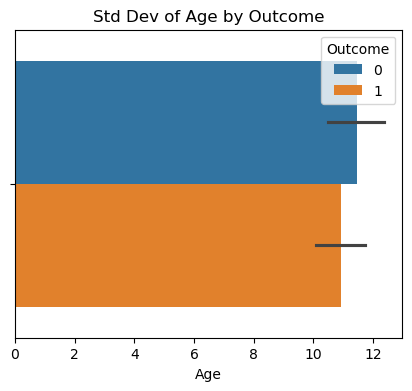

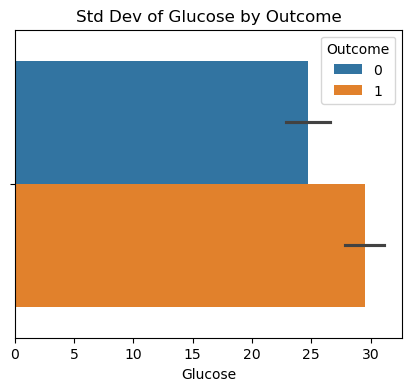

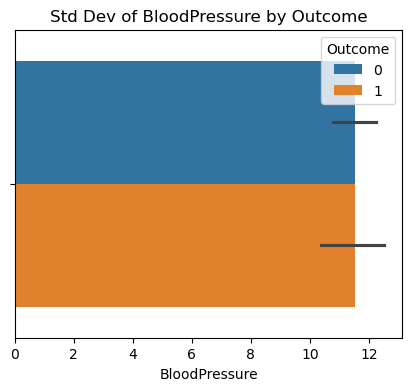

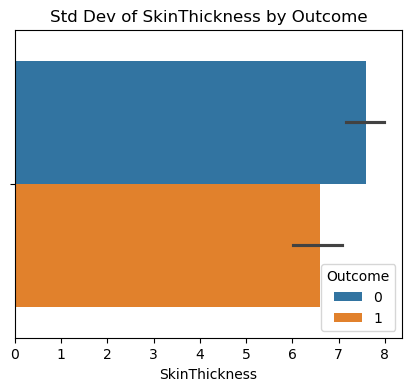

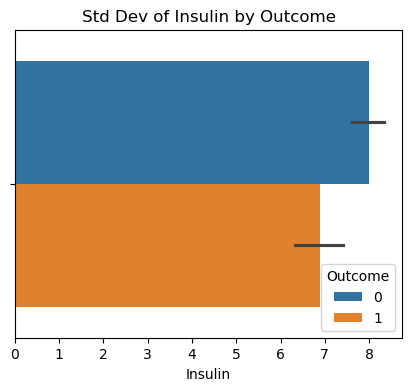

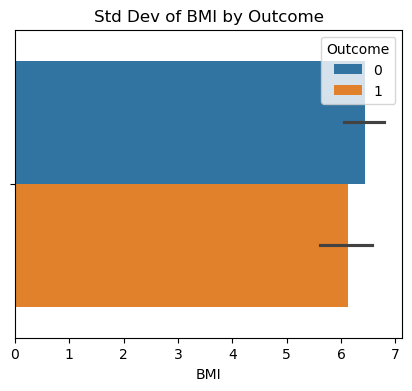

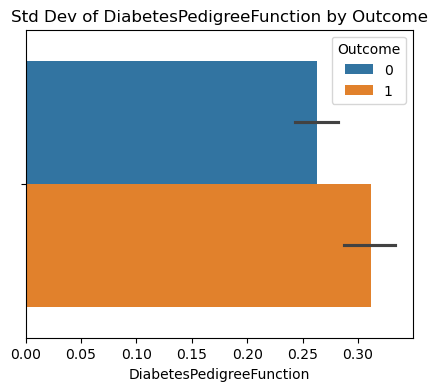

In [39]:
# Barplot – Standard Deviation by Outcome

for col in cols:
    plt.figure(figsize=(5,4))
    sns.barplot(x=df[col],hue=df['Outcome'],data=df, estimator='std')
    plt.title(f"Std Dev of {col} by Outcome")
    plt.show()

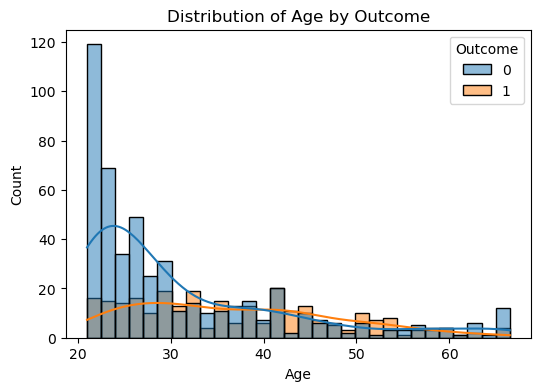

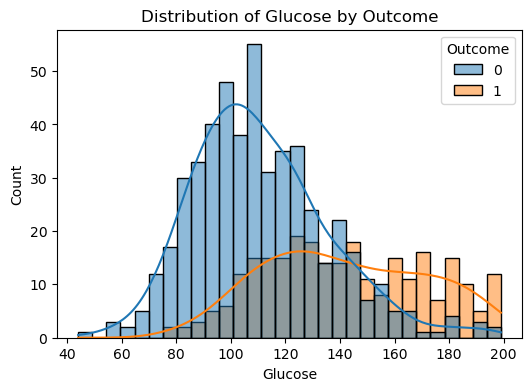

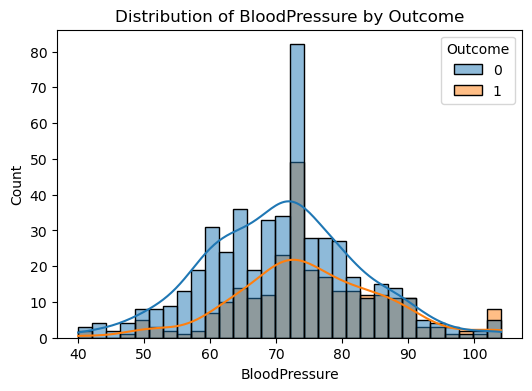

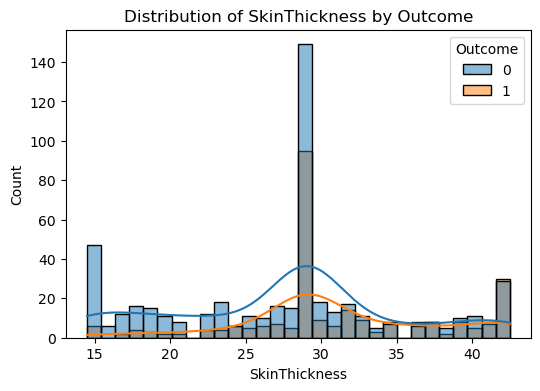

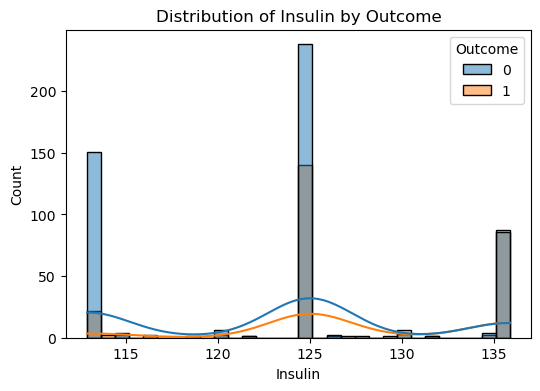

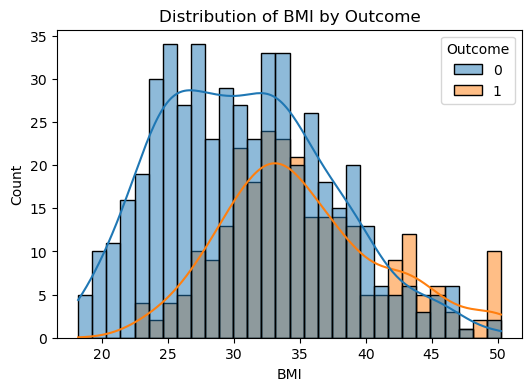

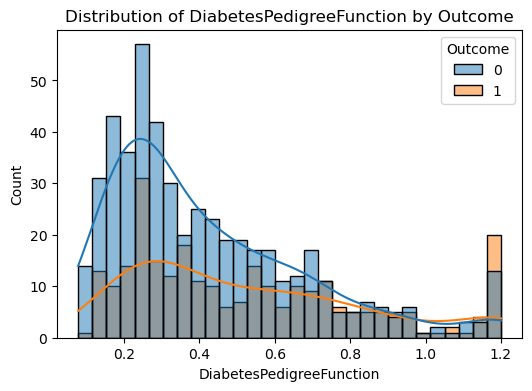

In [36]:
# Histogram + KDE (Distribution comparison)

for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="Outcome", kde=True, bins=30)
    plt.title(f"Distribution of {col} by Outcome")
    plt.show()

rejecting h0 --> significantly differ from eachother, and this particular column effect the outcome column
Age is dissimilar , Age of the person effect the outcome
Glucose is dissimilar , Glucose of the person effect the outcome
BloodPressure is dissimilar , BloodPressure of the person effect the outcome
SkinThickness is dissimilar , SkinThickness of the person effect the outcome
Insulin is dissimilar , Insulin of the person effect the outcome
BMI is dissimilar , BMI of the person effect the outcome
DiabetesPedigreeFunction is dissimilar , DiabetesPedigreeFunction of the person effect the outcome

In [40]:
def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.clip(df[col], lower, upper)

for col in ["Insulin", "BMI", "DiabetesPedigreeFunction"]:
    df[col] = remove_outliers(col)

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = [
    "Age",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction"
]

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,0.670968,0.50000,0.732143,0.527174,0.480499,0.489305,0.637363,1
1,1.0,0.264516,0.40625,0.517857,0.527174,0.262090,0.243316,0.219780,0
2,8.0,0.896774,0.37500,0.517857,0.527174,0.159126,0.529412,0.241758,1
3,1.0,0.290323,0.40625,0.303571,0.000000,0.308892,0.079323,0.000000,0
4,0.0,0.600000,0.00000,0.732143,1.000000,0.776911,1.000000,0.263736,1


In [42]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.3,random_state=42,stratify=y
)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

lr=LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Print the results
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.74

Confusion Matrix:
[[128  22]
 [ 38  43]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       150
           1       0.66      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



In [46]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
lr=LogisticRegression()
lr.fit(X_train, y_train)
y_pre= lr.predict(X_train)

# Print the results
print(f"Accuracy: {accuracy_score(y_train, y_pre):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_pre))
print("\nClassification Report:")
print(classification_report(y_train, y_pre))

Accuracy: 0.78

Confusion Matrix:
[[313  37]
 [ 79 108]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       350
           1       0.74      0.58      0.65       187

    accuracy                           0.78       537
   macro avg       0.77      0.74      0.75       537
weighted avg       0.78      0.78      0.78       537

